In [1]:
from google.colab import drive
import os

# Connecting to my Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os


base_dir = '/content/drive/MyDrive/CNN Project'

# Checking
print("Contents of your folder:", os.listdir(base_dir))

Contents of your folder: ['Lymphocyte images', 'Monocyte images']


In [3]:
# Defining the image size and batch size
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Loading the dataset from Google Drive folder
train_dataset = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',  # Since we have 2 classes (Monocyte vs Lymphocyte)
    shuffle=True,
    seed=123
)

# Checking what class names TensorFlow discovered
class_names = train_dataset.class_names
print("Class names found:", class_names)

Found 1000 files belonging to 2 classes.
Class names found: ['Lymphocyte images', 'Monocyte images']


In [10]:
# Scaling pixel values from [0, 255] down to [0.0, 1.0]
normalization_layer = tf.keras.layers.Rescaling(1./255)

# Applying normalization with lambda
normalized_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))

In [11]:
normalized_dataset

<_MapDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

In [12]:
model = models.Sequential([
    # 1. Normalization Layer (scales pixels from 0-255 to 0-1)
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),

    # --- Feature Extractor Blocks ---
    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # --- Classifier ---
    layers.Flatten(),                  # Flattens 2D matrices into a 1D vector
    layers.Dense(128, activation='relu'), # Hidden layer to learn combinations of features
    layers.Dense(1)                    # Output layer (1 neuron for binary classification)
])

# Compiling the model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Print a summary of network structure
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
EPOCHS = 5

history = model.fit(
    normalized_dataset,
    epochs=EPOCHS
)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.5000 - loss: 0.6947
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 640ms/step - accuracy: 0.5000 - loss: 0.6933
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 640ms/step - accuracy: 0.5000 - loss: 0.6932
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 630ms/step - accuracy: 0.5000 - loss: 0.6932
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 655ms/step - accuracy: 0.5000 - loss: 0.6932


An accuracy of 0.50 (50%) shows that the model is guessing at random.

We have to redo it and this time not use lambda normalization. Also introduce sigmoid function here...

In [14]:
# 1. Re-loading the dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    image_size=(128, 128),
    batch_size=32,
    label_mode='binary',
    shuffle=True,
    seed=123
)

print("Class names found:", train_dataset.class_names)

Found 1000 files belonging to 2 classes.
Class names found: ['Lymphocyte images', 'Monocyte images']


In [15]:
# 2. Building a clean, streamlined model with normalization built right in
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Using sigmoid forces output between 0 and 1!
])

model

<Sequential name=sequential_1, built=True>

In [16]:
# 3. Compiling with standard binary crossentropy
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
history = model.fit(train_dataset, epochs=10)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 641ms/step - accuracy: 0.4920 - loss: 0.7294
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 617ms/step - accuracy: 0.5530 - loss: 0.6911
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 620ms/step - accuracy: 0.6000 - loss: 0.6782
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 557ms/step - accuracy: 0.6880 - loss: 0.5974
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 564ms/step - accuracy: 0.8120 - loss: 0.4272
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 566ms/step - accuracy: 0.8380 - loss: 0.3604
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 563ms/step - accuracy: 0.8730 - loss: 0.2967
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 581ms/step - accuracy: 0.8800 - loss: 0.2671
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 557ms/step - accuracy: 0.8630 - loss: 0.2991
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 586ms/step - accuracy: 0.8880 - loss: 0.2457


Let's visualise the accuracy and training losses

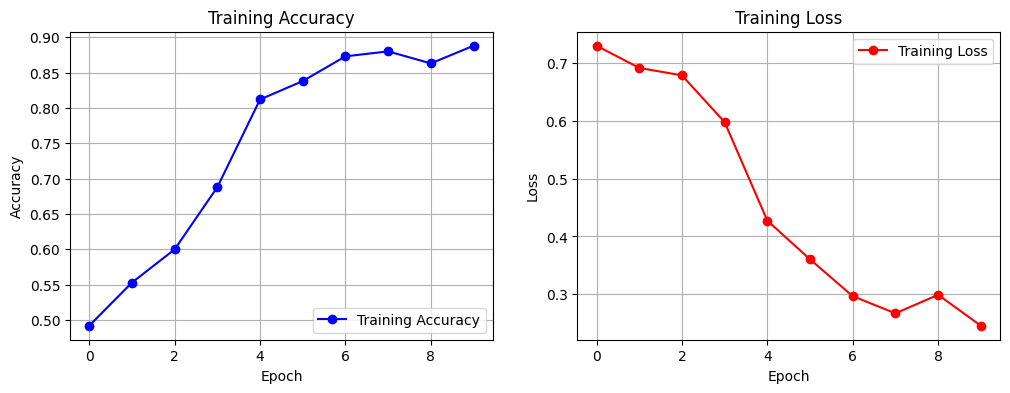

In [18]:
import matplotlib.pyplot as plt


acc = history.history['accuracy']
loss = history.history['loss']

epochs_range = range(len(acc))


plt.figure(figsize=(12, 4))

# 1. Accuracy Graph
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', marker='o')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# 2. Loss Graph
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='red', marker='o')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.show()

Running Predictions with different cell images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Raw prediction score: 0.0160
Prediction: This is likely a **Lymphocyte images**


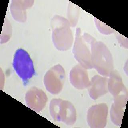

In [19]:
import numpy as np
from tensorflow.keras.preprocessing import image


def predict_blood_cell(img_path):
    # 1. Loading and resizing the image
    img = image.load_img(img_path, target_size=(128, 128))

    # 2. Converting the image to a NumPy array
    img_array = image.img_to_array(img)

    # 3. Expanding dimensions so it matches the batch shape (1, 128, 128, 3)
    img_array = np.expand_dims(img_array, axis=0)

    # 4. Make a prediction
    prediction = model.predict(img_array)
    score = prediction[0][0]

    # 5. Print the result based on our class names

    print(f"Raw prediction score: {score:.4f}")

    if score < 0.5:
        print(f"Prediction: This is likely a **{class_names[0]}**")
    else:
        print(f"Prediction: This is likely a **{class_names[1]}**")

    # Displaying the image
    display(img)

test_image_path = "/content/drive/MyDrive/CNN Project/Lymphocyte images/_0_1106.jpeg" #The link to the image

predict_blood_cell(test_image_path)

# ***The Prediction Above is Correct***

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Raw prediction score: 0.9772
Prediction: This is likely a **Monocyte images**


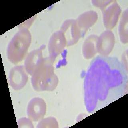

In [20]:
#Trying the prediction with another image
def predict_blood_cell(img_path):

    img = image.load_img(img_path, target_size=(128, 128))


    img_array = image.img_to_array(img)


    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    score = prediction[0][0]


    print(f"Raw prediction score: {score:.4f}")

    if score < 0.5:
        print(f"Prediction: This is likely a **{class_names[0]}**")
    else:
        print(f"Prediction: This is likely a **{class_names[1]}**")


    display(img)

test_image_path = "/content/drive/MyDrive/CNN Project/Monocyte images/_0_1276.jpeg"

predict_blood_cell(test_image_path)

# ***The Prediction Above is Also Correct***

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Raw prediction score: 0.1247
Prediction: This is likely a **Lymphocyte images**


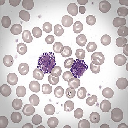

In [22]:
#TRYING THIS WITH BASOPHIL IMAGES FROM THE INTERNET
def predict_blood_cell(img_path):

    img = image.load_img(img_path, target_size=(128, 128))


    img_array = image.img_to_array(img)


    img_array = np.expand_dims(img_array, axis=0)


    prediction = model.predict(img_array)
    score = prediction[0][0]


    print(f"Raw prediction score: {score:.4f}")

    if score < 0.5:
        print(f"Prediction: This is likely a **{class_names[0]}**")
    else:
        print(f"Prediction: This is likely a **{class_names[1]}**")


    display(img)

test_image_path = "/content/Basophil practice 2.jfif"

predict_blood_cell(test_image_path)

# ***The Prediction Above is Incorrect***

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Raw prediction score: 0.0136
Prediction: This is likely a **Lymphocyte images**


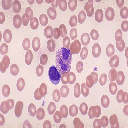

In [24]:
#TRYING THIS WITH EOSINOPHIL IMAGES FROM THE INTERNET
def predict_blood_cell(img_path):

    img = image.load_img(img_path, target_size=(128, 128))


    img_array = image.img_to_array(img)


    img_array = np.expand_dims(img_array, axis=0)


    prediction = model.predict(img_array)
    score = prediction[0][0]


    print(f"Raw prediction score: {score:.4f}")

    if score < 0.5:
        print(f"Prediction: This is likely a **{class_names[0]}**")
    else:
        print(f"Prediction: This is likely a **{class_names[1]}**")

    display(img)

test_image_path = "/content/eosinophil practice 2.jfif"

predict_blood_cell(test_image_path)

# ***The Prediction Above is Incorrect***

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Raw prediction score: 0.0009
Prediction: This is likely a **Lymphocyte images**


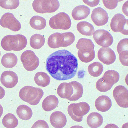

In [28]:
#TRYING THIS WITH MONOCYTE IMAGES FROM THE INTERNET
def predict_blood_cell(img_path):

    img = image.load_img(img_path, target_size=(128, 128))


    img_array = image.img_to_array(img)


    img_array = np.expand_dims(img_array, axis=0)


    prediction = model.predict(img_array)
    score = prediction[0][0]


    print(f"Raw prediction score: {score:.4f}")

    if score < 0.5:
        print(f"Prediction: This is likely a **{class_names[0]}**")
    else:
        print(f"Prediction: This is likely a **{class_names[1]}**")


    display(img)

test_image_path = "/content/monocyte practice 1.jpg"

predict_blood_cell(test_image_path)

# ***The Prediction Above is Incorrect***